## Paper Figure 5 - Functional clustering of neural responses

This script generates Figure 5 showing functional clustering of neural response types.
It includes UMAP visualization, cluster response profiles, coding score heatmaps,
population average responses, response metrics by cell type, and experience modulation analysis.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

# Visual behavior analysis package functions
import visual_behavior.visualization.utils as utils
import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities

# Clustering modules
from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

# Platform paper figure functions
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
# Figure saving
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_5')
os.makedirs(save_dir, exist_ok=True)

## Data Loading

#### Metadata tables

In [4]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Clustering results

In [5]:
glm_results_dir = loading.get_glm_results_dir()
clustering_dir = loading.get_clustering_results_dir()
data_dir = loading.get_clustering_results_dir()

# Load clustering results
feature_matrix = pd.read_hdf(os.path.join(data_dir, 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images': 'images', 'behavioral': 'behavior'})

n_clusters = 14
cluster_meta = pd.read_hdf(os.path.join(data_dir, f'cluster_metadata_{n_clusters}_clusters.h5'), key='df')

original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

# Load coding scores - normalized for clustering
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'across_session_normalized_platform_results_pivoted.h5'), key='df')
all_results = pd.read_hdf(os.path.join(glm_results_dir, 'all_results.h5'), key='df')

# Load UMAP results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


In [6]:
cluster_meta.groupby(['cell_type']).count()

,cluster_id,labels,ophys_experiment_id,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,...,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure,original_cluster_id,new_cluster_id
cell_type,,,,,,,,,,,,,,,,,,,,,
Excitatory,3298,3298,3298,3298,3298,3298,3298,3298,3298,3298,...,3298,3298,3298,3298,3298,3298,3298,3298,3298,3298
Sst Inhibitory,194,194,194,194,194,194,194,194,194,194,...,194,194,194,194,194,194,194,194,194,194
Vip Inhibitory,409,409,409,409,409,409,409,409,409,409,...,409,409,409,409,409,409,409,409,409,409


#### Multi-Session Dataframes

In [7]:
# Data type configuration
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

# Separate into change and non-change responses
change_mdf = multi_session_df[multi_session_df.is_change == True]
change_mdf = change_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

image_mdf = multi_session_df[multi_session_df.is_change == False]
image_mdf = image_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Omission responses
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]
omission_mdf = omission_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Remove outliers
threshold_percentile = 99.9  # for removing outliers for pl
image_mdf, image_outliers = processing.remove_outliers(image_mdf, threshold_percentile)
change_mdf, change_outliers = processing.remove_outliers(change_mdf, threshold_percentile)
omission_mdf, omission_outliers = processing.remove_outliers(omission_mdf, threshold_percentile)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.feather
there are 1881 experiments in the full multi_session_df
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.feather
there are 1879 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


In [8]:
#### TEST

In [9]:
import importlib
import visual_behavior.visualization.utils as utils
importlib.reload(utils)
import pandas as pd
o = utils.get_peak_outlier_cells(pd.concat([image_mdf, change_mdf, omission_mdf]), data_type='events')
print(len(o), 'cells exceed peak 0.4')

36 cells exceed peak 0.4


## Plotting

### Clustered coding scores

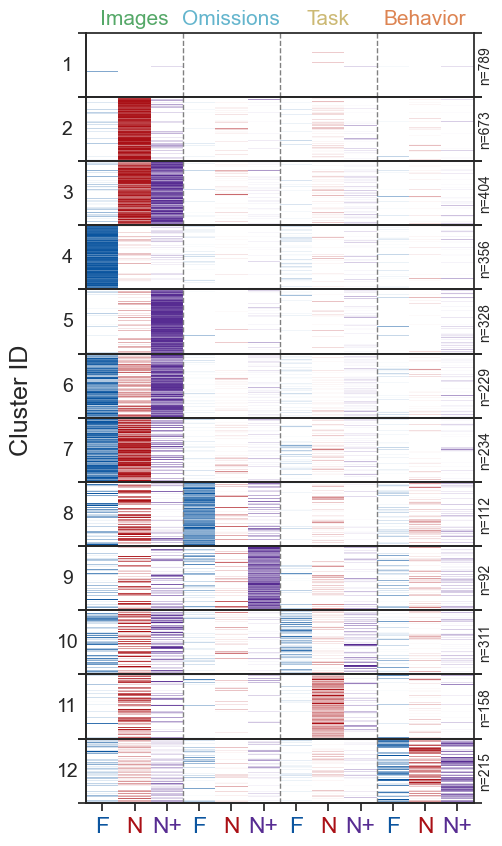

In [10]:
plotting.plot_coding_score_heatmap_matched(cluster_meta, feature_matrix, sort_by='cluster_id',
                                        session_colors=True, experience_index=None, title='',
                                        save_dir=save_dir, folder='cluster_properties', suffix='', ax=None);

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:1570: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  cluster_means = feature_matrix.merge(cluster_meta[['cluster_id']], on='cell_specimen_id').groupby('cluster_id').mean()


<Axes: ylabel='Cluster ID'>

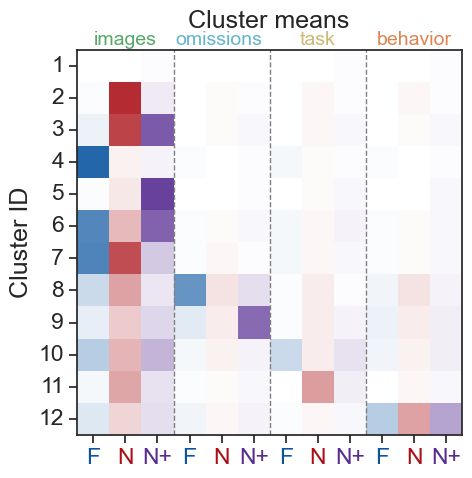

In [11]:
plotting.plot_cluster_means_remapped(
    feature_matrix,
    cluster_meta,
    save_dir=save_dir,
    folder='cluster_properties')


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:1581: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  cre_line_means = feature_matrix.merge(cluster_meta[['cre_line']], on='cell_specimen_id').groupby('cre_line').mean()


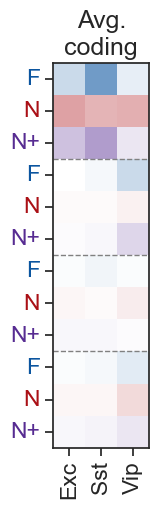

In [12]:
 #plot average coding scores for each cre line (average of matched cells only)
plotting.plot_cre_line_means_remapped(feature_matrix, cluster_meta, save_dir=save_dir, folder='cluster_properties')

### Average image, change, and omission responses per cluster

Generating Panel D: Population average responses...
Familiar
Novel
Novel +
Familiar
Novel
Novel +
Familiar
Novel
Novel +


array([<Axes: title={'center': 'Familiar'}>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

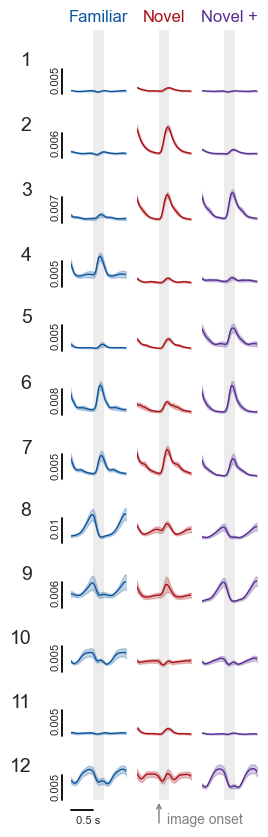

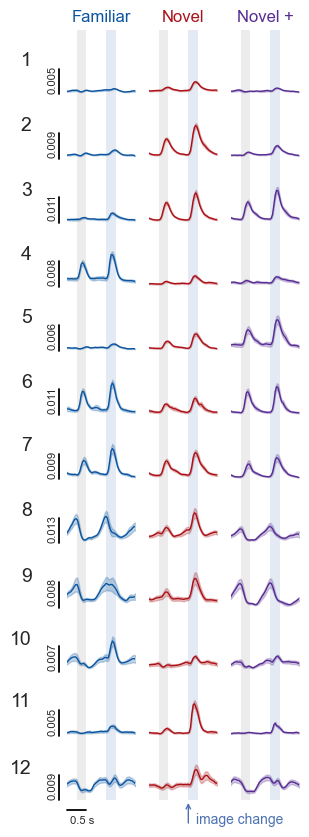

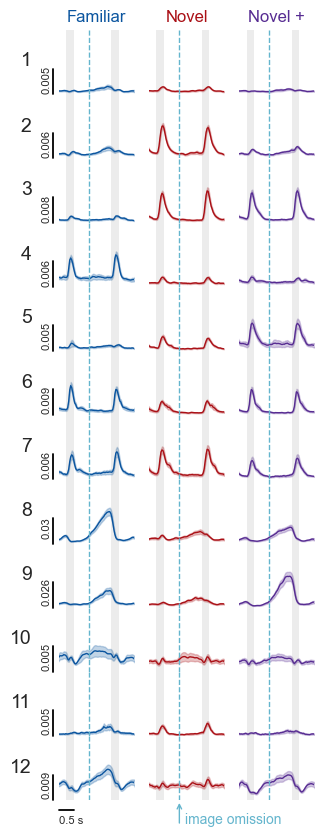

In [13]:
print("Generating Panel D: Population average responses...")

# Image responses
event_type = 'images'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    image_mdf,
    event_type,
    cluster_order=None,
    save_dir=save_dir,
    ax=None, apply_peak_threshold=True)

# Change responses
event_type = 'changes'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    change_mdf,
    event_type,
    with_pre_change=True,
    cluster_order=None,
    save_dir=save_dir,
    ax=None, apply_peak_threshold=True)

# Omission responses
event_type = 'omissions'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    omission_mdf,
    event_type,
    with_pre_change=True,
    cluster_order=None,
    save_dir=save_dir,
    ax=None, apply_peak_threshold=True)


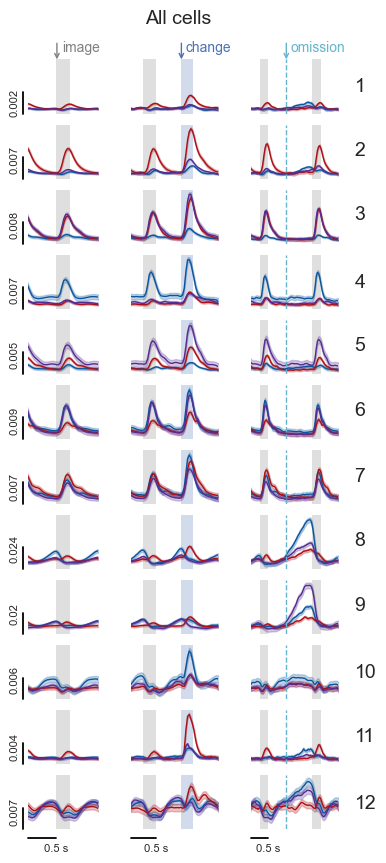

In [14]:
# all cre lines together
suptitle = 'All cells'

plotting.plot_population_average_response_for_clusters_as_rows_all_response_types(image_mdf, change_mdf, omission_mdf, 
                                                                             save_dir=save_dir, suptitle=suptitle, cluster_order=None, ax=None, apply_peak_threshold=True);

### Proportion cells per cluster per cell type 

In [15]:
# save_dir = r'\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_plots\figure_4\all_cre_clustering_113023'
metrics = processing.generate_merged_table_of_coding_score_and_model_free_metrics(cluster_meta, results_pivoted,
                                                                 data_type='events',
                                                                 session_subset='full_session',
                                                                 inclusion_criteria='platform_experiment_table',
                                                                 save_dir=loading.get_cell_metrics_dir())


# Replace dominant experience level cluster with correct one
cluster_metrics = processing.get_coding_score_metrics_for_clusters(cluster_meta, results_pivoted)

cluster_metrics = cluster_metrics.rename(columns={'dominant_experience_level':'dominant_experience_level_cluster', 
                                                  'dominant_feature': 'dominant_feature_cluster'})


metrics = metrics.rename(columns={'dominant_experience_level_cluster':'dominant_experience_level_old', 
                                                  'dominant_feature_cluster': 'dominant_feature_old'})

response_metrics = metrics.merge(cluster_metrics.reset_index()[['cluster_id', 'dominant_experience_level_cluster', 'dominant_feature_cluster']])


loading coding score and model free metrics table


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is dep

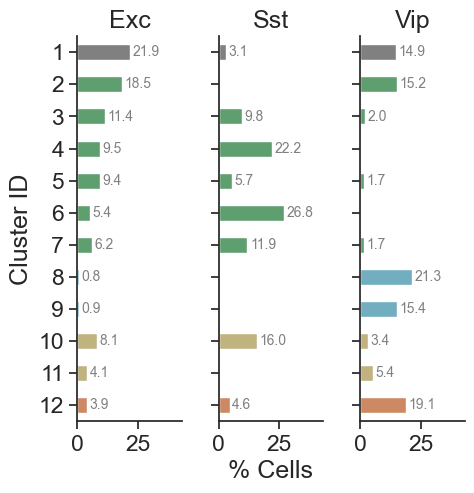

In [16]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')

plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature(tmp, cluster_order=None, square=True,
                                                                 col_to_group='cre_line', save_dir=save_dir)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is dep

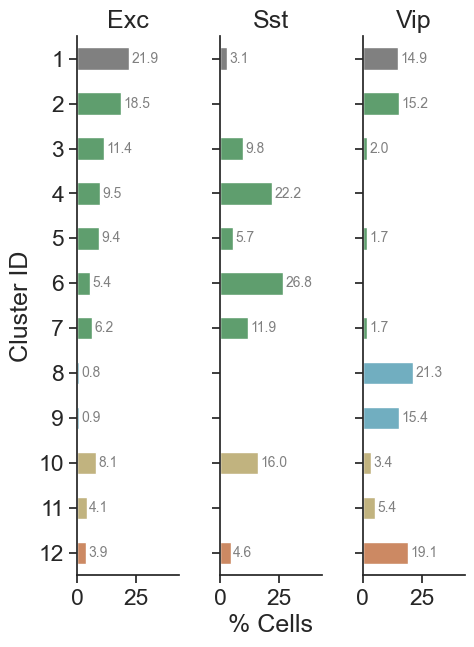

In [17]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')

plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature(tmp, cluster_order=None, square=False,
                                                                 col_to_group='cre_line', save_dir=save_dir)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2687: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=all_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2713: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i+1] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2713: FutureWarning: 

Passing `palette` without assigning `hue` is d

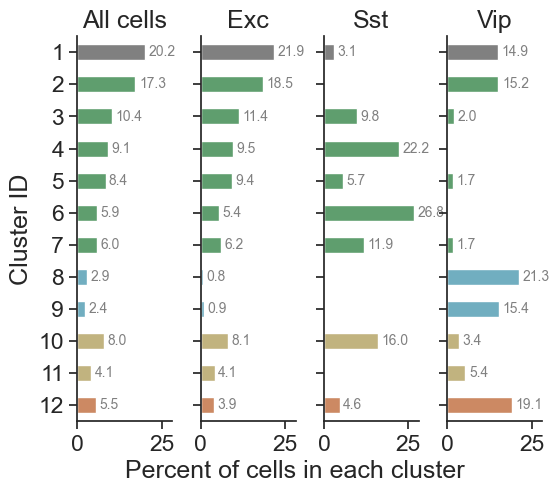

In [18]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')

plotting.plot_percent_cells_per_cluster_per_cre_and_all(tmp, col_to_group='cre_line', save_dir=save_dir)

array([<Axes: title={'center': 'Exc'}>, <Axes: title={'center': 'Sst'}>,
       <Axes: title={'center': 'Vip'}>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: ylabel='Percent of cells in each cluster'>, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: xlabel='Exc'>, <Axes: xlabel='Sst'>,
       <Axes: xlabel='Vip'>], dtype=object)

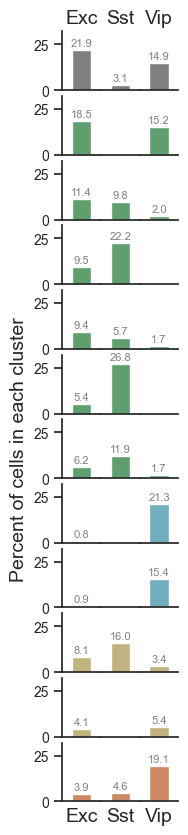

In [19]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')


plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature_xaxis(tmp, col_to_group='cre_line', match_height=True,
                                                            cluster_order=None, save_dir=save_dir)

In [20]:
###

### Top cluster properties

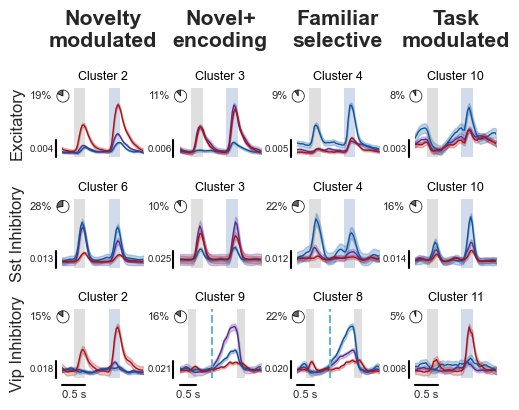

In [21]:
fontscale = 1.4

_, axG = plotting.plot_mean_cluster_response_profiles(
    image_mdf, change_mdf, omission_mdf, fig=None, bbox=None, fontsize_scale=fontscale,
    linewidth=1, fill_alpha=0.25, apply_peak_threshold=True)
# # bump the per-axes fonts the function sets internally (titles, tick labels, the
# # rotated cell-type row labels, and the pie % text live on the axes themselves)
# for _a in np.array(axG, dtype=object).ravel():
#     if _a.get_title():
#         _a.title.set_fontsize(_a.title.get_fontsize() * fontscale)
#     _a.tick_params(labelsize=8 * fontscale)
#     for _t in _a.texts:
#         _t.set_fontsize(_t.get_fontsize() * fontscale)

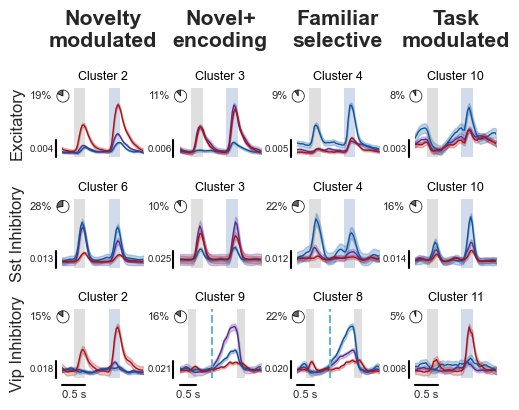

In [22]:
fontscale = 1.4

_, axG = plotting.plot_mean_cluster_response_profiles(
    image_mdf, change_mdf, omission_mdf, fig=None, bbox=None, fontsize_scale=fontscale,
    linewidth=1, apply_peak_threshold=True)
# # bump the per-axes fonts the function sets internally (titles, tick labels, the
# # rotated cell-type row labels, and the pie % text live on the axes themselves)
# for _a in np.array(axG, dtype=object).ravel():
#     if _a.get_title():
#         _a.title.set_fontsize(_a.title.get_fontsize() * fontscale)
#     _a.tick_params(labelsize=8 * fontscale)
#     for _t in _a.texts:
#         _t.set_fontsize(_t.get_fontsize() * fontscale)

## Composite figure (Figure 5 main)
Gutter-aware panel placement via `panel_grid`. Run the data-loading and per-panel plotting cells above first, then the import cell, then the composite cell.

In [23]:
from visual_behavior.visualization.panel_grid import (
    fig_setup, panel, panel_title, show_label_gutters, show_decoration_zones,
    check_label_overlap, auto_fit_left, snug_left_to_gutter, snug_top_to_gutter,
)


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_single_cell_examples.py:1778: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(feature_labels)
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_58710/2581410415.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axA_bar.set_xticklabels([t.get_text().capitalize() for t in axA_bar.get_xticklabels()])


loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5
Familiar
Novel
Novel +
Familiar
Novel
Novel +


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is dep

OVERLAP: axes of panel "A" intrudes into panel "B" (left gutter)
OVERLAP: axes of panel "A" intrudes into panel "A" (left gutter)
OVERLAP: axes of panel "B" intrudes into panel "B" (top gutter)
OVERLAP: axes of panel "B" intrudes into panel "B" (top gutter)
OVERLAP: axes of panel "G" intrudes into panel "G" (top gutter)


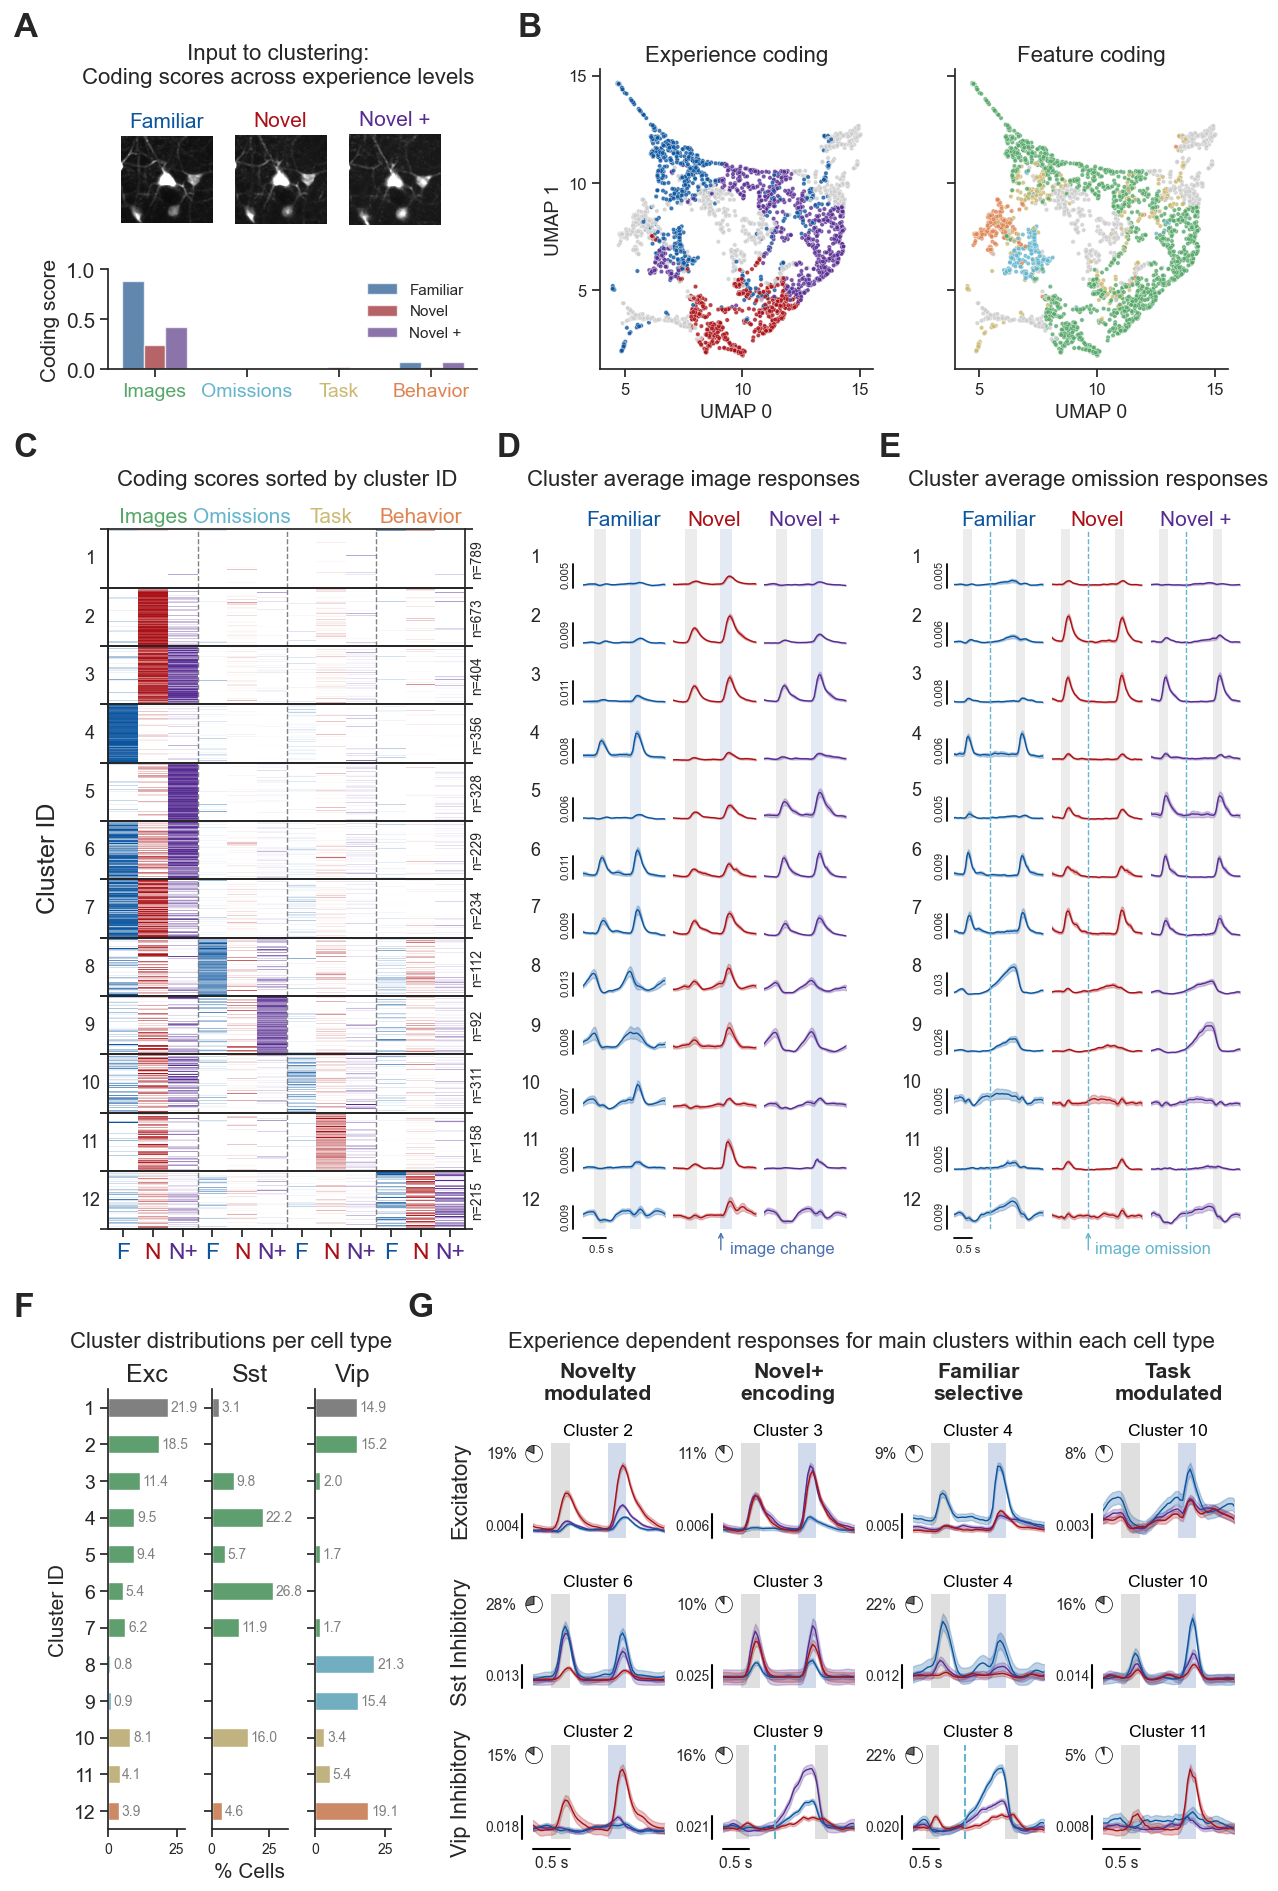

In [34]:
# Composite Figure 5 main - functional clustering of neural responses
#   A  single-cell coding example (3 ROI masks F/N/N+  +  coding-score barplot)
#   B  UMAP (Experience coding | Feature coding)
#   C  cluster coding-score heatmap (one row per cluster)
#   D  per-cluster population CHANGE responses   (clusters x F/N/N+)
#   E  per-cluster population OMISSION responses (clusters x F/N/N+)
#   F  % cells per cluster per cell type (Exc/Sst/Vip), colored by dominant feature
#   G  example clusters per cell type with proportion pies
#
# figsize + REGIONS were derived from the Figure 5 panel geometry and
# tuned against a data-free mock until check_label_overlap() was clean. The panel
# functions are embedded LIVE (no saved PNGs): C/D/E/F take an axes list, G takes
# fig+bbox, A is assembled from sf.plot_cell_zoom + pse.plot_coding_scores_for_cell.
#
# UPSTREAM (run the data-loading cells above first so these stable vars exist):
#   cluster_meta, feature_matrix, clustering_dir, image_mdf, change_mdf,
#   omission_mdf, results_pivoted, platform_cells_table, platform_experiments.
# Panels B and F are self-contained (they recompute their inputs) so they do NOT
# depend on the exploratory `umap_df`/`colors`/`tmp` that later cells overwrite.
import os
import numpy as np
import visual_behavior.visualization.ophys.summary_figures as sf

figsize = (12.3, 20.0)
fig = plt.figure(figsize=figsize)
fig_setup(fig)

# REGIONS [x0, x1, y0, y1] in figure fraction, y TOP-DOWN.
# Derived from the measured panel geometry (letter-anchor -> content, normalized into
# the panels' bounding box), then gaps tuned against a data-free mock until
# check_label_overlap was clean. Layout: A,B top | C,D,E middle |
# F bottom-left (tall, % cells) | G bottom-right (3x4 example clusters).
REGIONS = {
    'A': [0.040, 0.436, 0.017, 0.199],   # top-left  : single-cell coding example (plots nudged up)
    'B': [0.410, 0.990, 0.015, 0.198],   # top-right : UMAP (moved left + wider)
    'C': [0.001, 0.370, 0.224, 0.624],   # mid-left  : cluster coding heatmap (thinner)
    'D': [0.390, 0.680, 0.224, 0.624],   # mid       : change traces (aligned top+bottom with E)
    'E': [0.700, 1.000, 0.224, 0.624],   # mid-right : omission traces (wider)
    'F': [0.000, 0.310, 0.655, 0.920],   # BOTTOM-LEFT (moved up a little)
    'G': [0.320, 0.995, 0.675, 0.925],   # BOTTOM-RIGHT (bottom raised; top unchanged)
}
F_GUTTER = (20, 28)   # smaller letter gutter for F so the plot can sit further left

# Per-panel LEFT decoration setback (pt). Smaller than the 80pt default pulls each
# panel's y-label up against its letter gutter (no empty gap). Tuned in the mock so
# no label clips into the gutter -- if a panel ends up with too much/little left
# margin on the real render, nudge its value here. A's ROI row needs almost none;
# A's coding-score bar legitimately needs ~80 (2-line "Coding score" + ticks).
# setbacks bumped vs the mock because the real render's labels are wider than the mock's.
DP = {'A': (16, 0), 'B': (64, 0), 'C': (58, 0), 'D': (58, 0), 'E': (58, 0), 'F': (44, 0)}
DP_A_BAR = (80, 0)

cluster_order = np.sort(cluster_meta.cluster_id.unique())
n_cl = len(cluster_order)

# ---- A: 3 ROI masks (top sub-row) + 1 full-width coding-score bar (bottom) ----
A_CELL = 1086620671
Ax0, Ax1, Ay0, Ay1 = REGIONS['A']
A_top = [Ax0 + 0.03, Ax1 - 0.08, Ay0 + 0.13 * (Ay1 - Ay0), Ay0 + 0.58 * (Ay1 - Ay0)]   # ROI row: narrower + nudged right
A_bot = [Ax0 - 0.025, Ax1 - 0.05, Ay0 + 0.63 * (Ay1 - Ay0), Ay1]         # coding-score bar: left + narrower (right extent reduced)
# A/C/F left-spines are aligned to F's spine: gutter+decoration chosen so each panel's
# inner-axes left edge lands in the same 0.01 cell that F does (verified spine x0 == 0.08).
# 'A' letter at the top-left of the full A region (kept up top so it lines up with B's letter)
_axA_letter = panel(fig, [REGIONS['C'][0], Ax1], [REGIONS['B'][2], Ay1], 'A', dim=(1, 1)); _axA_letter.axis('off')  # letter aligned with B
axA_roi = np.atleast_1d(panel(fig, A_top[:2], A_top[2:], None, dim=(1, 3), wspace=0.25,
                              gutter_pt=(10, 28), decoration_pt=(4, 0)))
axA_bar = panel(fig, A_bot[:2], A_bot[2:], None, dim=(1, 1),
                gutter_pt=(0, 0), decoration_pt=(54, 0))

cell_meta_A = platform_cells_table[platform_cells_table.cell_specimen_id == A_CELL]
cell_drop_A = results_pivoted[results_pivoted.cell_specimen_id == A_CELL][
    processing.get_features_for_clustering() + ['experience_level']]
container_A = cell_meta_A.ophys_container_id.unique()[0]
exp_levels_A = ['Familiar', 'Novel', 'Novel +']
exp_colors_A = utils.get_experience_level_colors()
_dsets = globals().get('_fig5_A_datasets', {})   # cache so re-runs don't reload
for e, lvl in enumerate(exp_levels_A):
    oeid = platform_experiments[(platform_experiments.ophys_container_id == container_A) &
                                (platform_experiments.experience_level == lvl)].index.values[0]
    if oeid not in _dsets:
        print('loading dataset for', lvl, oeid, '...')
        _dsets[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
    ds = _dsets[oeid]
    a = axA_roi[e]
    try:
        roi_id = ds.cell_specimen_table.loc[A_CELL].cell_roi_id
        sf.plot_cell_zoom(ds.roi_masks, ds.max_projection, roi_id,
                          spacex=50, spacey=50, show_mask=False, ax=a)
    except Exception:
        a.axis('off')
    a.set_title(lvl, color=exp_colors_A[e], fontsize=15)
globals()['_fig5_A_datasets'] = _dsets
pse.plot_coding_scores_for_cell(cell_drop_A, ax=axA_bar)
axA_bar.tick_params(axis='both', labelsize=15)                   # y-ticks up, x-ticks down, matched
_acols = [t.get_color() for t in axA_bar.get_xticklabels()]      # capitalize x labels, keep colors
axA_bar.set_xticklabels([t.get_text().capitalize() for t in axA_bar.get_xticklabels()])
for _t, _c in zip(axA_bar.get_xticklabels(), _acols):
    _t.set_color(_c); _t.set_fontsize(14)   # x-tick labels (set_xticklabels above resets the size)
_lh, _ll = axA_bar.get_legend_handles_labels()   # move the F/N/N+ legend inside, upper-right
if _lh:
    axA_bar.legend(_lh, _ll, loc='upper right', fontsize=11, frameon=False)
axA_bar.yaxis.label.set_fontsize(15)             # 'Coding score' y-label

# ---- B: UMAP - Experience coding + Feature coding ----
# Self-contained: recompute the UMAP subset + per-cell colors here so panel B does
# NOT depend on the notebook-state `colors`/`edge_colors`/`umap_df`, which later
# cells overwrite (colors -> an 8-element palette, umap_df -> the full table).
_umapB = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')
_umapB['cell_specimen_id'] = cluster_meta.index.values
_umapB = _umapB.set_index('cell_specimen_id')
_mainB = cluster_meta[cluster_meta.cluster_id != 1]          # drop the cluster-1 outlier
_umapB = _umapB.loc[_mainB.index.values]
_keep = _umapB[_umapB.x < 16].index.values                  # drop far outliers
_mainB = _mainB.loc[_keep]; _umapB = _umapB.loc[_keep]

_exp = utils.get_experience_level_colors(); _gray = (0.8, 0.8, 0.8)
_expdict  = {1: _gray, 2: _exp[1], 3: _exp[2], 4: _exp[0], 5: _gray, 6: _exp[2],
             7: _gray, 8: _exp[0], 9: _exp[2], 10: _exp[0], 11: _gray, 12: _gray}
_feat = plotting.get_feature_colors_with_gray()
_featdict = {1: _gray, 2: _feat[1], 3: _feat[1], 4: _feat[1], 5: _gray, 6: _feat[1],
             7: _gray, 8: _feat[2], 9: _feat[2], 10: _feat[3], 11: _gray, 12: _feat[4]}
_cid = _mainB.loc[_umapB.index.values, 'cluster_id'].values
_colB = [_expdict[c] for c in _cid]
_edgeB = [_featdict[c] for c in _cid]

axB = np.atleast_1d(panel(fig, REGIONS['B'][:2], REGIONS['B'][2:], 'B', has_title=True,
                          dim=(1, 2), wspace=0.3, sharey=True, title_room_pt=8,
                          gutter_pt=(20, 28), decoration_pt=(46, 0)))  # tighter letter->plot gap
sns.scatterplot(data=_umapB, x='x', y='y', s=10, ax=axB[0], color=_colB, alpha=0.8)
axB[0].set_title('Experience coding'); axB[0].set_xlabel('UMAP 0'); axB[0].set_ylabel('UMAP 1')
sns.scatterplot(data=_umapB, x='x', y='y', s=10, ax=axB[1], color=_edgeB, alpha=0.8)
axB[1].set_title('Feature coding'); axB[1].set_xlabel('UMAP 0')
axB[1].set_ylabel(''); axB[1].tick_params(labelleft=False)   # shared y; drop the stray 'y' label
for _a in axB:                                               # matching ticks in increments of 5
    _a.set_xticks([5, 10, 15]); _a.set_yticks([5, 10, 15])
    _a.title.set_fontsize(16); _a.xaxis.label.set_fontsize(14); _a.yaxis.label.set_fontsize(14)
    _a.tick_params(labelsize=12)

# ---- C: cluster coding-score heatmap (one row per cluster) ----
axC = list(np.atleast_1d(panel(fig, REGIONS['C'][:2], REGIONS['C'][2:], 'C',
                               dim=(n_cl, 1), hspace=0.0, has_title=True, title_room_pt=24,
                               gutter_pt=(20, 28), decoration_pt=(45, 0))))  # spine aligned to F; title room for headers
plotting.plot_coding_score_heatmap_matched(
    cluster_meta, feature_matrix, sort_by='cluster_id', cluster_order=cluster_order,
    session_colors=True, experience_index=None, title='',
    save_dir=None, folder=None, suffix='', ax=axC)
for _a in axC:                                   # smaller 'Cluster ID' y-label
    if _a.get_ylabel():
        _a.yaxis.label.set_fontsize(13)

# ---- D: population CHANGE responses per cluster ----
axD_grid = np.array(panel(fig, REGIONS['D'][:2], REGIONS['D'][2:], 'D',
                          dim=(n_cl, 3), hspace=0.0, wspace=0.1, sharey='row', sharex=True,
                          has_title=True, title_room_pt=24, gutter_pt=(20, 28), decoration_pt=DP['D']))
axD_flat = [a for row in axD_grid for a in row]
plotting.plot_population_average_response_for_clusters_as_rows_split(
    change_mdf, 'changes', with_pre_change=True, cluster_order=cluster_order,
    ax=axD_flat, save_dir=None, cluster_id_fontsize=13, fill_alpha=0.25,
    cluster_id_xoffset=0.9, arrow_label_fontsize=12, apply_peak_threshold=True)

# ---- E: population OMISSION responses per cluster ----
axE_grid = np.array(panel(fig, REGIONS['E'][:2], REGIONS['E'][2:], 'E',
                          dim=(n_cl, 3), hspace=0.0, wspace=0.1, sharey='row', sharex=True,
                          has_title=True, title_room_pt=24, gutter_pt=(20, 28), decoration_pt=DP['E']))
axE_flat = [a for row in axE_grid for a in row]
plotting.plot_population_average_response_for_clusters_as_rows_split(
    omission_mdf, 'omissions', with_pre_change=True, cluster_order=cluster_order,
    ax=axE_flat, save_dir=None, cluster_id_fontsize=13, fill_alpha=0.25,
    cluster_id_xoffset=0.9, arrow_label_fontsize=12, apply_peak_threshold=True)

# D/E experience-level column labels (Familiar/Novel/Novel+): centered over each
# column (x=0.5), close to the plots (small pad), bigger (15pt)
for _grid in (axD_grid, axE_grid):
    for _a in _grid[0]:
        _t = _a.get_title()
        if _t:
            _a.set_title(_t, color=_a.title.get_color(), fontsize=15, x=0.5, pad=3)

# ---- F: % cells per cluster per cell type (colored by dominant feature) ----
# Self-contained: rebuild cluster_meta + per-cluster dominant_feature from stable
# inputs (cluster_meta, results_pivoted), not the notebook-state `tmp` (overwritten).
_cm_metrics = processing.get_coding_score_metrics_for_clusters(cluster_meta, results_pivoted)
_domF = _cm_metrics['dominant_feature']          # index = cluster_id
tmpF = cluster_meta.copy()
if 'cell_specimen_id' not in tmpF.columns:
    tmpF = tmpF.reset_index()
tmpF['dominant_feature_cluster'] = tmpF['cluster_id'].map(_domF)

axF = list(np.atleast_1d(panel(fig, REGIONS['F'][:2], REGIONS['F'][2:], 'F', has_title=True,
                               title_room_pt=34,   # extra top room so the section title sits above the Exc/Sst/Vip headers
                               dim=(1, 3), wspace=0.35, sharey=True,   # wider gaps so bar value labels show
                               gutter_pt=F_GUTTER, decoration_pt=DP['F'])))
plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature(
    tmpF, col_to_group='cre_line', square=True, cluster_order=cluster_order,
    save_dir=None, ax=axF)
# sharey: only the leftmost column shows cluster-ID tick labels (axes already share y).
# y-tick + "Cluster ID" label keep their full autoscaled size; DP['F'] is sized so that
# (bigger) label sits snug against the letter gutter.
for _a in axF[1:]:
    _a.tick_params(labelleft=False)
for _a in axF:
    _a.tick_params(axis='x', labelsize=10)   # % Cells tick labels
axF[0].tick_params(axis='y', labelsize=14)   # cluster-ID ticks match panel C
axF[0].yaxis.label.set_fontsize(15)          # 'Cluster ID' y-label (matched with x-label)
for _a in axF:
    _a.xaxis.label.set_fontsize(15)          # '% Cells' x-label (matched with y-label)

# ---- G: example clusters per cell type (with proportion pies) ----
# reserve the letter + gutter with panel(), then embed the multi-axes grid via fig+bbox
axG_lbl = panel(fig, REGIONS['G'][:2], [0.655, REGIONS['G'][3]], 'G', dim=(1, 1))  # letter aligned with F
axG_lbl.axis('off')
# Insets tuned in the mock so the embedded grid's col-0 cell-type labels (drawn at
# ax.transAxes x=-0.55) and 2-line column headers clear the G letter gutter.
G_INSET_L, G_INSET_T = 0.105, 0.052   # left: grid near the G letter; top: lowered so the section title fits above
G_FONT = 1.4   # scale up all of panel G's fonts
G_bbox = [REGIONS['G'][0] + G_INSET_L, REGIONS['G'][2] + G_INSET_T,
          REGIONS['G'][1], REGIONS['G'][3]]
_, axG = plotting.plot_mean_cluster_response_profiles(
    image_mdf, change_mdf, omission_mdf, fig=fig, bbox=G_bbox, fontsize_scale=G_FONT,
    linewidth=1, fill_alpha=0.25, apply_peak_threshold=True)
# bump the per-axes fonts the function sets internally (titles, tick labels, the
# rotated cell-type row labels, and the pie % text live on the axes themselves)
for _a in np.array(axG, dtype=object).ravel():
    if _a.get_title():
        _a.title.set_fontsize(_a.title.get_fontsize() * G_FONT)
    _a.tick_params(labelsize=8 * G_FONT)
    for _t in _a.texts:
        _t.set_fontsize(_t.get_fontsize() * G_FONT)
for _a in np.array(axG, dtype=object).ravel():   # cell-type row labels 1 pt smaller
    for _t in _a.texts:
        if 'Excitatory' in _t.get_text() or 'Inhibitory' in _t.get_text():
            _t.set_fontsize(_t.get_fontsize() - 1)

# ---- snap inner-panel y-labels right up against their gutters (MEASURED, not guessed) ----
# B/D/E aren't leftmost, so their labels can't spill into the margin like A/C/F -- this
# rescales each about its right edge so the leftmost label lands at gutter+2pt. Pass each
# panel's own gutter (B uses 20pt, D/E use 32pt). G can't snap (its row labels would hit
# the letter); A/C/F are left aligned already, so leave them.
snug_left_to_gutter(fig, REGIONS, only=['B'], gutter_pt=(20, 28))
snug_left_to_gutter(fig, REGIONS, only=['D', 'E'], gutter_pt=(20, 28))
# (snug_top intentionally NOT applied to C/D/E: leaving the has_title room in place drops each
# plot's TOP down a little -- bottoms unchanged -- so the section titles have clear room above the headers)
# snug_top_to_gutter(fig, REGIONS, only=['C', 'D', 'E'])

# nudge the D and E panel letters ever so slightly to the right
for _lax in fig.axes:
    if getattr(_lax, '_panel_grid_label_ax', False):
        _lp = _lax.get_position()
        if abs(_lp.x0 - REGIONS['D'][0]) < 0.008 or abs(_lp.x0 - REGIONS['E'][0]) < 0.008:
            _lax.set_position([_lp.x0 + 0.003, _lp.y0, _lp.width, _lp.height])

# ---- panel section titles (bold headers on the letter line; nudge fontsize/dy_pt if needed) ----
panel_title(fig, (REGIONS['A'][0] - 0.04, REGIONS['A'][1]),
            'Input to clustering:\nCoding scores across experience levels',
            y_frac=0.038, fontsize=16)
panel_title(fig, (0.08, REGIONS['C'][1]), 'Coding scores sorted by cluster ID',
            y_frac=0.245, fontsize=16)
# separate titles for D (image) and E (omission), each on its own panel's letter line
panel_title(fig, (0.420, REGIONS['D'][1]), 'Cluster average image responses',
            y_frac=0.245, fontsize=16, ha='left')
panel_title(fig, (0.730, REGIONS['E'][1]), 'Cluster average omission responses',
            y_frac=0.245, fontsize=16, ha='left')
panel_title(fig, (0.050, REGIONS['F'][1]), 'Cluster distributions per cell type',
            y_frac=0.676, fontsize=16)
panel_title(fig, (0.390, REGIONS['G'][1]),
            'Experience dependent responses for main clusters within each cell type',
            y_frac=0.676, fontsize=16)

# ---- audit + save ----
# NOTE: A, C, F will each report a "left gutter" intrusion -- this is EXPECTED and intended:
# their spines are aligned to F (far left), so the rotated y-labels sit in the gutter strip,
# beside (not overlapping) the panel letters, which are at the top. Any OTHER warning is real.
check_label_overlap(fig, REGIONS, gutter_pt=F_GUTTER)
utils.save_figure(fig, figsize, save_dir, 'composite', 'figure_5_main_composite', formats=['.png', '.pdf'])
